In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("/kaggle/input/notebooks/jigishadas/ssi-creation/dataset_with_ssi.csv")

df.head()

,function_count,parameter_count,variable_count,declaration_count,if_count,for_count,while_count,switch_count,return_count,call_count,...,expression_density,variable_density,statement_density,nesting_factor,cyclomatic_estimate,avg_parameters,language,repository,function,SSI
0,1,2,2,1,1,0,0,0,0,4,...,0.025974,0.025974,0.025974,0.129870,2,2.0,java,molgenis/molgenis,L1Cache.put,-1.407771
1,1,0,7,4,1,1,0,0,1,1,...,0.010309,0.072165,0.010309,0.092784,3,0.0,java,belaban/JGroups,RequestTable.size,-0.685910
2,1,3,8,4,0,0,0,0,0,17,...,0.010601,0.028269,0.010601,0.045936,1,3.0,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample,0.810129
3,1,4,0,0,0,0,0,0,1,2,...,0.000000,0.000000,0.000000,0.117647,1,4.0,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync,-2.041741
4,2,6,4,2,6,0,0,0,3,12,...,0.002342,0.009368,0.002342,0.037471,7,3.0,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...,2.781887


In [3]:
X = df.drop(
    columns=[
        "language",
        "repository",
        "function",
        "SSI"
    ]
)

y = df["SSI"]

print(X.shape)
print(y.shape)

(2000, 32)
(2000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [6]:
y_pred = rf.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.2155
RMSE : 0.4731
R²   : 0.9730


In [8]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
17,ast_nodes,0.505342
19,internal_nodes,0.229382
18,leaf_nodes,0.184523
13,identifier_count,0.021215
11,assignment_count,0.011768
14,block_count,0.010763
30,cyclomatic_estimate,0.005867
2,variable_count,0.004525
23,branch_density,0.003482
4,if_count,0.002468


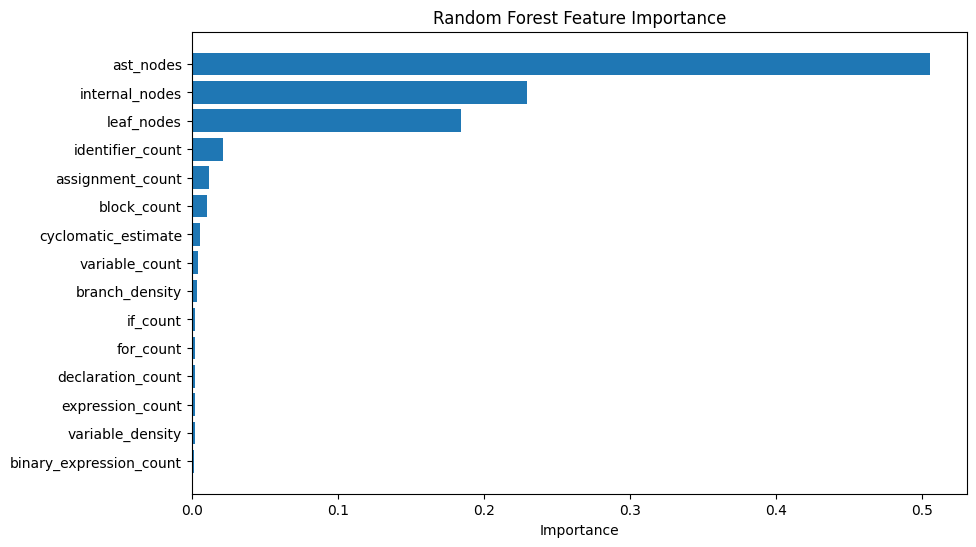

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()